# Ultra Low Complexity Noise Suppression Model (ULCNet - Simplified)

Author:-

- Aryan Gupta (230150003)

This notebook implements an end-to-end simplified version of the ULCNet model based on the paper ["Ultra Low Complexity Deep Learning Based Noise Suppression"](https://ieeexplore.ieee.org/document/10448353), and compares it with a [manual STFT-ISTFT noise suppression method](https://ieeexplore.ieee.org/abstract/document/1163209). I have implemented two versions (one heavy and one light) of the ULCNet with significant difference in the number of parameters.

<!-- Features:

- STFT + Power Law Compression
- Two-stage Network (CRN + CNN)
- Training + Inference
- Audio Reconstruction -->

**Manual STFT-ISTFT Method Features:**

- **Classical signal processing approach (no learning involved)**

- **STFT-based processing pipeline:**
  waveform → STFT → magnitude modification → ISTFT

- **Noise estimation:**
  Noise profile estimated from initial segment (~0.5 seconds) of noisy audio

- **Spectral subtraction:**
  Estimated noise magnitude is subtracted from noisy magnitude spectrum

- **Non-negativity constraint:**
  Negative magnitudes are clamped to zero after subtraction

- **Phase preservation:**
  Original noisy phase is reused for reconstruction

- **Optional power-law compression:**
  Can apply same α = 0.3 compression for fair comparison with DL model

- **No training required:**
  Works directly on test data (rule-based method)

- **Sensitive to assumptions:**
  Performance depends on quality of noise estimation (fails if speech is present in initial segment)

- **Same STFT configuration as DL model (for fair comparison):**
  n_fft = 512, hop = 16 ms, window = 32 ms

**ULCNet Heavy Version Features:**

- **CRN-based architecture (Convolutional Recurrent Network)**

- **Stage 1 (CRN):**
  - Convolutional encoder + Bidirectional GRU + Fully connected layer
  - Predicts magnitude mask over frequency bins

- **Stage 2 (CNN refinement):**
  Convolutional layers refine complex spectrum (real & imaginary components)

- **Higher model capacity:**
  More parameters than light version → better performance but higher computation

- **Temporal modeling:**
  Bidirectional GRU captures long-range dependencies in speech

- **Magnitude + phase modeling:**
  Stage 1 handles magnitude, Stage 2 refines complex representation

- **Power-law compression:**
  α = 0.3 used for stable training

- **Loss computation:**
  MSE on compressed real and imaginary STFT components

- **Flexible architecture modes:**
  - Full model (Stage 1 + Stage 2)
  - Stage 1 only (ablation)
  - No compression mode

- **Same STFT configuration:**
  n_fft = 512 (257 bins), hop = 16 ms, window = 32 ms

**ULCNet Light Version Features:**

- **Subband GRU input size: 64**
  (Computed as band_width × channels = 32 × 2 for real & imaginary components)

- **Subband GRU architecture:**
  hidden_size = 128, 2 layers, bidirectional (captures temporal dependencies in both directions)

- **Frequency pooling cascade:**
  - 3-stage downsampling along frequency axis (48 → 24 → 12 → 6)
  - (increases receptive field and reduces computational load)

- **Loss computation:**
  Mean Squared Error (MSE) in frequency domain on **power-law compressed real and imaginary components**

- **Power-law compression:**
  Compression factor α = 0.3 applied to stabilize dynamic range before model input

- **Fully connected layer:**
  2048 → 257 (maps GRU output to frequency bins, where 257 = n_fft/2 + 1)

- **Complex mask estimation:**
  Unconstrained complex mask (no activation), allowing both attenuation and amplification

- **Two-stage enhancement pipeline:**
  - Stage 1: magnitude mask estimation
  - Stage 2: complex refinement using CNN

- **STFT parameters:**
  - n_fft = 512 → 257 frequency bins
  - window = 32 ms, hop = 16 ms


## Install and import libraries


In [98]:
# Install dependencies (run once)
# !pip install torch torchaudio librosa soundfile tqdm

In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm
import os
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import Audio, display

## Setup Variation Mode


In [100]:
MODEL_VARIANT = "light"  # "heavy" or "light"

MODE = 0   # 0=vanilla, 1=stage1 only, 2=no compression

USE_STAGE2 = (MODE != 1)
USE_COMPRESSION = (MODE != 2)
ALPHA = 0.3 if USE_COMPRESSION else 1.0

In [135]:
# ====================== GLOBAL CONFIG ======================
RUN_MODE = "test_all_models"
# RUN_MODE = "train_and_test_single"
# RUN_MODE = "plot_only"
# Options:
# "train_and_test_single" -> train the model and evaluate on test set (saves CSV)
# "test_all_models" -> run evaluation across all saved weights
# "plot_only" -> only load CSV and plot

FORCE_RECOMPUTE = False

QUICK_TEST = True  # Set to True for quick testing (fewer epochs, smaller dataset)
# QUICK_TEST = False

## File location setup


In [102]:
RUNNING_ON_KAGGLE = False
if 'KAGGLE_URL_BASE' in os.environ:
    RUNNING_ON_KAGGLE = True

In [103]:
if RUNNING_ON_KAGGLE:
    # training params
    CLEAN_DIR = "/kaggle/input/datasets/sayuksh/denoising-audio-collection/clean_trainset_56spk_wav/clean_trainset_56spk_wav"
    NOISY_DIR = "/kaggle/input/datasets/sayuksh/denoising-audio-collection/noisy_trainset_56spk_wav/noisy_trainset_56spk_wav"

    # testing params
    TEST_FILE = "/kaggle/input/datasets/sayuksh/denoising-audio-collection/noisy_testset_wav/noisy_testset_wav/p232_101.wav"
    
else:
    # training params
    CLEAN_DIR = "./clean_trainset_wav"
    NOISY_DIR = "./noisy_trainset_wav"

    # testing params
    TEST_FILE = "./app2_data/noisy/p232_004.wav"

In [104]:
if RUNNING_ON_KAGGLE:
    # test set directory location
    TEST_NOISE_DIR = "/kaggle/input/datasets/sayuksh/denoising-audio-collection/noisy_testset_wav/noisy_testset_wav"
    TEST_CLEAN_DIR = "/kaggle/input/datasets/sayuksh/denoising-audio-collection/clean_testset_wav/clean_testset_wav"
else:
    # test set directory location
    TEST_NOISE_DIR = "./noisy_testset_wav/"
    TEST_CLEAN_DIR = "./clean_testset_wav/"

In [105]:
OUTPUT_DIR = 'output/'

# manual mode output location
MANUAL_OUTPUT_PATH = OUTPUT_DIR + 'manual_test_output.wav'
DL_OUTPUT_PATH = OUTPUT_DIR + "enhanced_output.wav"

### Result CSV files location


In [106]:
# ====================== CSV FILES ======================
EPOCH_CSV = "req_csvs/epoch_vs_loss.csv"
PARAM_CSV = "req_csvs/loss_vs_params.csv"

### Mode weights folder location


In [107]:
# ====================== MODE CONFIGURATION ======================
MODES = {
    "heavy_no_compression": {
        "folder": "model_weights/heavy_no_compression",
        "label": "Heavy (No Compression)",
        "color": "red"
    },
    "heavy_stage1_only": {
        "folder": "model_weights/heavy_stage1_only",
        "label": "Heavy (Stage1)",
        "color": "orange"
    },
    "heavy_vanilla": {
        "folder": "model_weights/heavy_vanilla",
        "label": "Heavy (Vanilla)",
        "color": "darkred"
    },
    "light_full": {
        "folder": "model_weights/light_full",
        "label": "Light (Full)",
        "color": "blue"
    },
    "light_no_comp": {
        "folder": "model_weights/light_no_comp",
        "label": "Light (No Compression)",
        "color": "cyan"
    },
    "light_stage1_only": {
        "folder": "model_weights/light_stage1_only",
        "label": "Light (Stage1)",
        "color": "navy"
    }
}

## Setting up GPU


In [108]:
# GPU Setup and Verification
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)

# Check and set GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    print("CUDA device initialized and cache cleared")
else:
    print("WARNING: CUDA not available. Using CPU (training will be slow)")

print("=" * 60)


GPU CONFIGURATION
Device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Version: 12.1
GPU Memory: 4.29 GB
CUDA device initialized and cache cleared


## Dataset Loader


In [109]:
class SimpleDataset(torch.utils.data.Dataset):

    def __init__(self, clean_files, noise_files, sr=16000):
        self.clean = clean_files
        self.noise = noise_files
        self.sr = sr
        
        # Validate that files exist and can be loaded
        self.valid_indices = []
        for idx in range(len(self.clean)):
            try:
                if idx >= len(self.clean) or idx >= len(self.noise):
                    continue
                clean_path = self.clean[idx]
                noise_path = self.noise[idx]
                
                # continue if path does not exist
                if not os.path.exists(clean_path):
                    print(f"Warning: File not found at index {idx} - {clean_path}")
                    continue
                if not os.path.exists(noise_path):
                    print(f"Warning: File not found at index {idx} - {noise_path}")
                    continue
                    
                c, _ = librosa.load(clean_path, sr=self.sr)
                n, _ = librosa.load(noise_path, sr=self.sr)
                
                if len(c) > 0 and len(n) > 0:
                    self.valid_indices.append(idx)
            except Exception as e:
                print(f"Warning: Skipping invalid file pair at index {idx}: {e}")
                continue
        
        if len(self.valid_indices) == 0:
            raise ValueError("No valid audio files found in dataset!")
        
        print(f"Dataset initialized with {len(self.valid_indices)} valid samples out of {len(self.clean)} total")


    def __len__(self):
        return len(self.valid_indices)


    def __getitem__(self, idx):
        if idx < 0 or idx >= len(self.valid_indices):
            raise IndexError(f"Index {idx} out of range for dataset with {len(self.valid_indices)} samples")
            
        actual_idx = self.valid_indices[idx]
        
        try:
            c, _ = librosa.load(self.clean[actual_idx], sr=self.sr)
            n, _ = librosa.load(self.noise[actual_idx], sr=self.sr)
            
            if len(c) == 0 or len(n) == 0:
                raise ValueError(f"Empty audio file at index {actual_idx}")
            
            L = min(len(c), len(n))
            c = c[:L]
            n = n[:L]        

            return torch.tensor(n, dtype=torch.float32), torch.tensor(c, dtype=torch.float32)
        except Exception as e:
            print(f"Error loading files at index {idx} (actual: {actual_idx}): {e}")
            raise


In [110]:
# ---- Collate function for DataLoader --------------------------------------
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """
    batch: list of tuples (mix_tensor, clean_tensor) with variable lengths
    Returns:
      mix_padded: [B, Lmax]
      clean_padded: [B, Lmax]
      lengths: tensor([L1, L2, ...])
    """
    mixes = [b[0].float() for b in batch]
    cleans = [b[1].float() for b in batch]
    lengths = torch.tensor([m.shape[0] for m in mixes], dtype=torch.long)

    mix_p = pad_sequence(mixes, batch_first=True)   # [B, Lmax]
    clean_p = pad_sequence(cleans, batch_first=True) # [B, Lmax]

    return mix_p, clean_p, lengths


## Load dataset


### Training set


In [111]:
# Prepare train dataset
clean_files = []
noise_files = []

# clean files append
for filename in os.listdir(CLEAN_DIR):
    if filename.endswith(".wav"):
        clean_files.append(os.path.join(CLEAN_DIR, filename))
        
# noise files append
for filename in os.listdir(NOISY_DIR):
    if filename.endswith(".wav"):
        noise_files.append(os.path.join(NOISY_DIR, filename))

# sort to ensure order is good
clean_files.sort()
noise_files.sort()

if QUICK_TEST:  
    clean_files = clean_files[:5]
    noise_files = noise_files[:5]

print(f"Found {len(clean_files)} clean files and {len(noise_files)} noise files")

Found 5 clean files and 5 noise files


### Test set


In [112]:
# load filenames
test_noisy_files = []
test_clean_files = []

for filename in os.listdir(TEST_NOISE_DIR):
    if filename.endswith(".wav"):
        test_noisy_files.append(os.path.join(TEST_NOISE_DIR, filename))
for filename in os.listdir(TEST_CLEAN_DIR):
    if filename.endswith(".wav"):
        test_clean_files.append(os.path.join(TEST_CLEAN_DIR, filename))

# Sort to ensure matching order
test_noisy_files.sort()
test_clean_files.sort()

if QUICK_TEST:        
    test_noisy_files = test_noisy_files[:5]
    test_clean_files = test_clean_files[:5]

# Manual STFT Baseline Comparison

This section implements a classical spectral subtraction baseline to compare with the deep learning approach.


In [113]:
# ====================== MANUAL STFT BASELINE FUNCTION ======================

def estimate_noise_profile(noisy_wav, sr=16000, duration=0.5, n_fft=512, hop=256):
    """
    Estimate noise spectrum from the beginning of noisy audio using spectral subtraction.
    
    Args:
        noisy_wav: 1D numpy array or torch tensor
        sr: sample rate
        duration: duration in seconds to use for noise estimation
        n_fft: FFT size
        hop: hop length
        
    Returns:
        noise_mag: 1D numpy array of estimated noise magnitude spectrum [freq_bins]
    """
    # convert torch to numpy
    if isinstance(noisy_wav, torch.Tensor):
        noisy_wav = noisy_wav.cpu().numpy()
    
    # Extract noise segment from beginning
    n_samples = int(sr * duration)
    noise_segment = noisy_wav[:n_samples]
    
    # Compute STFT
    noise_spec = librosa.stft(noise_segment, n_fft=n_fft, hop_length=hop)
    
    # Average magnitude across time frames to get noise profile
    noise_mag = np.mean(np.abs(noise_spec), axis=1)  # [freq_bins]
    
    return noise_mag


def manual_stft_denoise(noisy_wav, noise_mag, sr=16000, n_fft=512, hop=256, 
                        alpha=0.3, use_compression=True, subtraction_factor=1.0):
    """
    Manual spectral subtraction denoising using STFT.
    
    Args:
        noisy_wav: 1D numpy array or torch tensor (noisy audio)
        noise_mag: 1D numpy array (estimated noise magnitude spectrum)
        sr: sample rate
        n_fft: FFT size
        hop: hop length
        alpha: power-law compression factor (same as in DL model)
        use_compression: whether to apply power-law compression
        subtraction_factor: factor for noise magnitude subtraction (1.0 = full subtraction)
        
    Returns:
        enhanced_wav: 1D numpy array (denoised audio, same length as input)
    """
    
    # convert torch to numpy
    if isinstance(noisy_wav, torch.Tensor):
        noisy_wav = noisy_wav.cpu().numpy()
    
    orig_len = len(noisy_wav)
    
    # Compute STFT of noisy signal
    noisy_spec = librosa.stft(noisy_wav, n_fft=n_fft, hop_length=hop)  # [freq_bins, time_frames]
    
    # Extract magnitude and phase
    noisy_mag = np.abs(noisy_spec)
    noisy_phase = np.angle(noisy_spec)
    
    # Apply power-law compression to magnitude (matching DL pipeline)
    if use_compression:
        noisy_mag_compressed = np.sign(noisy_mag) * np.abs(noisy_mag) ** alpha
        noise_mag_compressed = np.sign(noise_mag[:, None]) * np.abs(noise_mag[:, None]) ** alpha
    else:
        noisy_mag_compressed = noisy_mag
        noise_mag_compressed = noise_mag[:, None]
    
    # Spectral subtraction in compressed domain
    subtracted_mag = np.maximum(noisy_mag_compressed - subtraction_factor * noise_mag_compressed, 0.0)
    
    # Decompress back to linear magnitude
    if use_compression:
        enhanced_mag = np.sign(subtracted_mag) * np.abs(subtracted_mag) ** (1.0 / alpha)
    else:
        enhanced_mag = subtracted_mag
    
    # Reconstruct complex spectrogram and ISTFT
    enhanced_spec = enhanced_mag * np.exp(1j * noisy_phase)
    enhanced_wav = librosa.istft(enhanced_spec, hop_length=hop, n_fft=n_fft)
    
    # Fix length (ISTFT may have different length due to padding)
    enhanced_wav = librosa.util.fix_length(enhanced_wav, size=orig_len)
    
    return enhanced_wav


## Step 1: Single Sample Test (Sanity Check)


In [114]:
# ---- Select first test sample ----
if len(test_noisy_files) > 0 and len(test_clean_files) > 0:
    manual_sample_idx = 2 #chosen randomly
    sample_noisy_path = test_noisy_files[manual_sample_idx]
    sample_clean_path = test_clean_files[manual_sample_idx]
    
    # Load audio
    sample_noisy, sr_sample = librosa.load(sample_noisy_path, sr=16000)
    sample_clean, _ = librosa.load(sample_clean_path, sr=16000)
    
    # Trim to same length
    min_len = min(len(sample_noisy), len(sample_clean))
    sample_noisy = sample_noisy[:min_len]
    sample_clean = sample_clean[:min_len]
    
    print(f"Sample loaded: {sample_noisy_path}")
    print(f"Duration: {len(sample_noisy) / sr_sample:.2f} seconds")
    print(f"Sample rate: {sr_sample} Hz")

    # ---- Manual STFT denoising ----
    print("\n--- Running Manual STFT Denoising ---")
    noise_profile = estimate_noise_profile(sample_noisy, sr=sr_sample, duration=0.5)
    sample_manual = manual_stft_denoise(
        sample_noisy, 
        noise_profile, 
        sr=sr_sample, 
        n_fft=512, 
        hop=256,
        alpha=ALPHA,
        use_compression=USE_COMPRESSION
    )
    # save processed file
    sf.write(MANUAL_OUTPUT_PATH, sample_manual, sr_sample)

    print("✓ Manual STFT denoising complete")

    # ---- Compute MSE losses ----
    print("\n--- Computing Losses ---")
    mse_noisy = np.mean((sample_noisy - sample_clean) ** 2)
    mse_manual = np.mean((sample_manual[:min_len] - sample_clean) ** 2)
    
    print(f"MSE (Noisy):  {mse_noisy:.6f}")
    print(f"MSE (Manual): {mse_manual:.6f}")
    
    # output audio files
    print('='*60)
    print('Noisy Audio')
    display(Audio(sample_noisy_path))
    
    print('Clean Audio')
    display(Audio(sample_clean_path))
    
    print('Manually processed Audio')
    display(Audio(MANUAL_OUTPUT_PATH))
    
    

Sample loaded: ./noisy_testset_wav/p232_003.wav
Duration: 7.18 seconds
Sample rate: 16000 Hz

--- Running Manual STFT Denoising ---
✓ Manual STFT denoising complete

--- Computing Losses ---
MSE (Noisy):  0.001053
MSE (Manual): 0.002042
Noisy Audio


Clean Audio


Manually processed Audio


Starting waveform comparison...
Generating waveform plots...


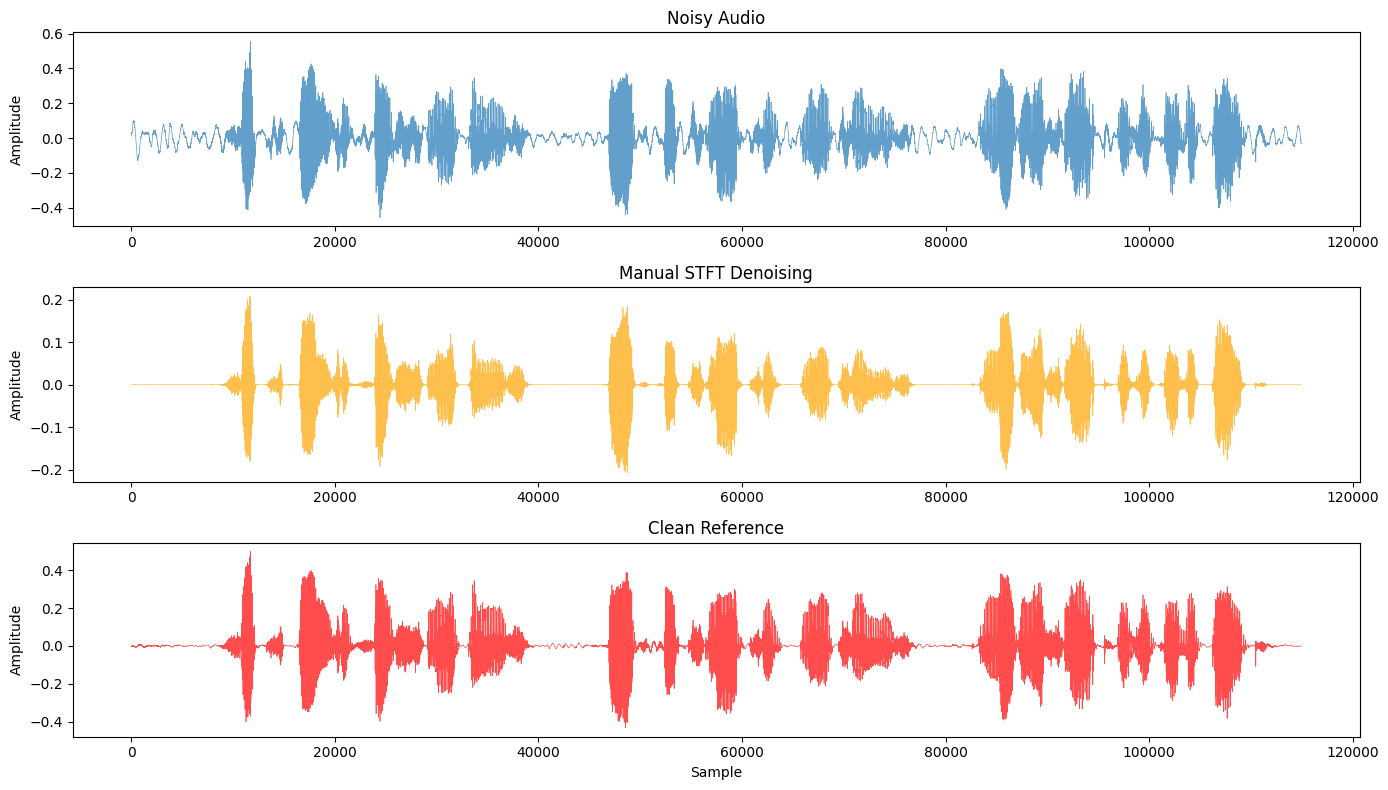

✓ Waveform plots displayed


In [115]:
# ---- Waveform Comparison ----
print("Starting waveform comparison...")
if len(test_noisy_files) > 0:
    print("Generating waveform plots...")
    
    # Create figure with appropriate number of subplots
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))

    # Plot noisy
    axes[0].plot(sample_noisy, alpha=0.7, linewidth=0.5)
    axes[0].set_title('Noisy Audio')
    axes[0].set_ylabel('Amplitude')

    # Plot manual
    axes[1].plot(sample_manual, alpha=0.7, linewidth=0.5, color='orange')
    axes[1].set_title('Manual STFT Denoising')
    axes[1].set_ylabel('Amplitude')

    # Plot clean
    axes[2].plot(sample_clean, alpha=0.7, linewidth=0.5, color='red')
    axes[2].set_title('Clean Reference')
    axes[2].set_ylabel('Amplitude')
    axes[2].set_xlabel('Sample')

    plt.tight_layout()
    plt.show()
    print("✓ Waveform plots displayed")
else:
    print(f"No test files available for plotting. Please check {TEST_CLEAN_DIR} and {TEST_NOISE_DIR}.")

## Step 2: Full Dataset Evaluation


In [116]:
# ---- Evaluate on full test set ----
def evaluate_baselines_manual(noisy_files, clean_files, device, noise_profile=None, sr=16000):
    """
    Evaluate both manual STFT on all test samples.
    
    Returns:
        results: dict with accuracy metrics
    """
    total_mse_noisy = 0.0
    total_mse_manual = 0.0
    total_samples = 0
    sample_count = 0
    
    manual_outcomes = []
    
    print("Evaluating baselines on test set...")
    
    for nfile, cfile in tqdm(zip(noisy_files, clean_files), total=len(noisy_files)):
        try:
            # Load audio
            noisy_wav, _ = librosa.load(nfile, sr=sr)
            clean_wav, _ = librosa.load(cfile, sr=sr)
            
            # Trim to same length
            L = min(len(noisy_wav), len(clean_wav))
            noisy_wav = noisy_wav[:L]
            clean_wav = clean_wav[:L]
            
            # Manual STFT denoising
            if noise_profile is None:
                noise_profile_sample = estimate_noise_profile(noisy_wav, sr=sr, duration=0.5)
            else:
                noise_profile_sample = noise_profile
                
            manual_wav = manual_stft_denoise(
                noisy_wav, 
                noise_profile_sample,
                sr=sr,
                n_fft=512,
                hop=256,
                alpha=ALPHA,
                use_compression=USE_COMPRESSION
            )
            
            # Limit to original length
            manual_wav = manual_wav[:L]
            
            # Compute MSE
            mse_noisy_sample = np.mean((noisy_wav - clean_wav) ** 2)
            mse_manual_sample = np.mean((manual_wav - clean_wav) ** 2)
            
            total_mse_noisy += mse_noisy_sample * L
            total_mse_manual += mse_manual_sample * L
            total_samples += L
            sample_count += 1
            
            manual_outcomes.append(mse_manual_sample)
            
        except Exception as e:
            print(f"Warning: Skipping sample {nfile}: {e}")
            continue
    
    # Compute averages
    avg_mse_noisy = total_mse_noisy / total_samples if total_samples > 0 else float('inf')
    avg_mse_manual = total_mse_manual / total_samples if total_samples > 0 else float('inf')
    
    return {
        'avg_mse_noisy': avg_mse_noisy,
        'avg_mse_manual': avg_mse_manual,
        'manual_outcomes': manual_outcomes,
        'sample_count': sample_count
    }


In [117]:
# Run evaluation
if len(test_noisy_files) > 0:
    print("="*60)
    print("BASELINE COMPARISON EVALUATION")
    print("="*60)
    
    results = evaluate_baselines_manual(test_noisy_files, test_clean_files, device)
    
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    print(f"Samples evaluated: {results['sample_count']}")
    print(f"\nAverage MSE (Noisy):              {results['avg_mse_noisy']:.6f}")
    print(f"Average MSE (Manual STFT):       {results['avg_mse_manual']:.6f}")
    
    # Compute improvements
    improvement_manual = (results['avg_mse_noisy'] - results['avg_mse_manual']) / results['avg_mse_noisy'] * 100
    
    print(f"\n--- Improvement over Noisy Baseline ---")
    print(f"Manual STFT:  {improvement_manual:+.2f}%")
        
    print("="*60)
else:
    print(f"No test files available for plotting. Please check {TEST_CLEAN_DIR} and {TEST_NOISE_DIR}.")

BASELINE COMPARISON EVALUATION
Evaluating baselines on test set...


100%|██████████| 5/5 [00:00<00:00, 30.95it/s]


RESULTS
Samples evaluated: 5

Average MSE (Noisy):              0.001597
Average MSE (Manual STFT):       0.003058

--- Improvement over Noisy Baseline ---
Manual STFT:  -91.46%


# ULCNet Heavy Version

This section implements a heavy CNN based noise suppression model. It somewhats looks like the paper but CNN based.


## STFT and Power-Law Compression


In [118]:

def power_compress(x, alpha=0.3, use_compression=True):
    """Power-law compression."""
    if not use_compression:
        return x
    return torch.sign(x) * torch.abs(x) ** alpha

def power_decompress(x, alpha=0.3, use_compression=True):
    """Power-law decompression."""
    if not use_compression:
        return x
    return torch.sign(x) * torch.abs(x) ** (1 / alpha)


# ---- Batched STFT / ISTFT helpers ----------------------------------------
# Updated to support batched signals (B, L) or single (L,) - GPU optimized
def compute_stft(wav, n_fft=512, hop=256, win_length=512):
    """
    Compute STFT on GPU.
    wav: [B, L] or [L] tensor on GPU
    Returns: [B, F, T] or [F, T] complex tensor on same device
    """
    if wav.dim() == 1:
        wav = wav.unsqueeze(0)
    # STFT stays on same device as input (GPU if input is on GPU)
    return torch.stft(wav, n_fft=n_fft, hop_length=hop, win_length=win_length,
                      return_complex=True, center=True)

def compute_istft(spec, n_fft=512, hop=256, win_length=512, length=None):
    """
    Compute ISTFT on GPU.
    spec: [B, F, T] or [F, T] complex tensor on GPU
    Returns: [B, L] or [L] waveform on same device as input
    """
    # ISTFT stays on same device as input (GPU if input is on GPU)
    return torch.istft(spec, n_fft=n_fft, hop_length=hop, win_length=win_length,
                       length=length, center=True)


## Stage 1: CRN (Magnitude Mask)


In [119]:

class CRNStage(nn.Module):
    def __init__(self, freq_bins=257):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, (1,3), padding=(0,1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, (1,3), padding=(0,1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, (1,3), padding=(0,1)),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.gru = nn.GRU(
            input_size=128*freq_bins,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Sequential(
            nn.Linear(512, freq_bins),
            nn.Sigmoid()
        )


    def forward(self, x):
        # x: [B,1,T,F]
        B,C,T,F = x.shape

        x = self.conv(x)

        x = x.permute(0,2,1,3)
        x = x.reshape(B, T, -1)

        x,_ = self.gru(x)

        mask = self.fc(x)

        return mask


## Stage 2: CNN (Complex Mask)


In [120]:

class CNNStage(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(2, 32, (1,3), padding=(0,1)),
            nn.ReLU(),

            nn.Conv2d(32, 32, (1,3), padding=(0,1)),
            nn.ReLU(),

            nn.Conv2d(32, 2, 1)
        )


    def forward(self, x):
        return self.net(x)


## Full ULCNet Heavy Model


In [121]:
class ULCNet(nn.Module):
    def __init__(self, freq_bins=257, alpha=0.3, mode=0):
        super().__init__()
        self.alpha = alpha
        self.mode = mode
        self.use_stage2 = (mode != 1)
        self.use_compression = (mode != 2)

        self.stage1 = CRNStage(freq_bins)
        self.stage2 = CNNStage() if self.use_stage2 else None

    def forward(self, mag, phase):
        mag = mag.unsqueeze(1)
        mask = self.stage1(mag)

        if not self.use_stage2:
            return mask, None, None

        yr = mask * torch.cos(phase)
        yi = mask * torch.sin(phase)
        feat = torch.stack([yr, yi], dim=1)

        cmask = self.stage2(feat)
        mr = cmask[:, 0]
        mi = cmask[:, 1]
        return mask, mr, mi

# Light Model Classes (Paper-like Implementation)


## Helpers


In [122]:
class DepthwiseSeparableConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=(1, 3), padding=(0, 1), stride=(1, 1)):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_ch, in_ch, kernel_size=kernel_size, stride=stride,
            padding=padding, groups=in_ch, bias=False
        )
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.PReLU(out_ch)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.act(x)
        return x

In [123]:
class ChannelwiseFeatureReorientation(nn.Module):
    """Approximation of the paper's channelwise feature reorientation."""
    def __init__(self, freq_bins=257, band_bins=48, band_hop=32):
        super().__init__()
        self.freq_bins = freq_bins
        self.band_bins = band_bins
        self.band_hop = band_hop
        # 8 bands of 48 bins with hop 32 -> 272 padded bins
        self.pad_to = band_bins + band_hop * 7

    def forward(self, x):
        # x: [B, T, F]
        b, t, f = x.shape
        if f < self.pad_to:
            x = F.pad(x, (0, self.pad_to - f))
        elif f > self.pad_to:
            x = x[..., :self.pad_to]
        bands = x.unfold(dimension=-1, size=self.band_bins, step=self.band_hop)
        # [B, T, 8, 48] -> [B, 8, T, 48]
        return bands.permute(0, 2, 1, 3).contiguous()

In [124]:
class FrequencyBiGRU(nn.Module):
    """BiGRU applied along the frequency axis for each time frame."""
    def __init__(self, in_features, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_features,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        # x: [B, C, T, F]
        b, c, t, f = x.shape
        x = x.permute(0, 2, 3, 1).contiguous().view(b * t, f, c)  # [B*T, F, C]
        y, _ = self.gru(x)
        y = y.view(b, t, f, -1).permute(0, 3, 1, 2).contiguous()   # [B, 2H, T, F]
        return y

## Stage 1


In [125]:
class PaperLikeStage1(nn.Module):
    """Lightweight CRN-style magnitude mask estimator."""
    def __init__(self, freq_bins=257, band_bins=48, band_hop=32, num_bands=8):
        super().__init__()
        self.num_bands = num_bands
        self.reorient = ChannelwiseFeatureReorientation(freq_bins, band_bins, band_hop)

        # Paper-like depthwise-separable conv stack
        self.conv1 = DepthwiseSeparableConv2d(num_bands, 32)
        self.conv2 = DepthwiseSeparableConv2d(32, 64)
        self.conv3 = DepthwiseSeparableConv2d(64, 96)
        self.conv4 = DepthwiseSeparableConv2d(96, 128)

        # one gentle pooling step to keep the frequency resolution light
        self.pool = nn.MaxPool2d((1, 2), stride=(1, 2))

        # frequency-axis recurrent block (bidirectional)
        self.fgru = FrequencyBiGRU(128, hidden_size=64)

        # pointwise projection after the recurrent block
        self.pw = nn.Conv2d(128, 64, kernel_size=1, bias=False)
        self.pw_bn = nn.BatchNorm2d(64)
        self.pw_act = nn.PReLU(64)

        # subband temporal GRU blocks (shared weights across subbands)
        # Paper specifies: 2 GRU layers with 128 units each (NOT bidirectional)
        # After 3x pooling (48→24→12→6), divided by 8 bands = 1 bin/band
        # Feature per band: 64 (from pw) * 1 (band_width) = 64
        self.band_gru = nn.GRU(
            input_size=64, hidden_size=128,
            num_layers=2, batch_first=True, bidirectional=False
        )

        # two FC layers for the intermediate magnitude mask
        # Input: 8 bands * 128 (non-bidirectional GRU) = 1024
        self.fc1 = nn.Linear(num_bands * 128, 257)
        self.fc2 = nn.Linear(257, 257)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, T, F]
        x = self.reorient(x)                 # [B, 8, T, 48]
        x = self.conv1(x)                    # [B, 32, T, 48] - no pooling for first layer
        x = self.pool(self.conv2(x))         # [B, 64, T, 24] - pool after conv2 (per paper)
        x = self.pool(self.conv3(x))         # [B, 96, T, 12] - pool after conv3 (per paper)
        x = self.pool(self.conv4(x))         # [B, 128, T, 6]  - pool after conv4 (per paper)
        x = self.fgru(x)                     # [B, 128, T, 6]
        x = self.pw_act(self.pw_bn(self.pw(x)))  # [B, 64, T, 6]

        b, c, t, f = x.shape
        # Actual number of bands is limited by available frequency bins
        effective_bands = min(self.num_bands, max(1, f))  # Don't exceed number of freq bins
        band_width = max(1, f // effective_bands)
        band_feats = []

        for band_idx in range(effective_bands):
            # Carefully handle band slicing to avoid empty tensors
            start_idx = band_idx * band_width
            end_idx = min((band_idx + 1) * band_width, f)  # Clip to frequency dimension
            
            if start_idx >= f:  # Skip if beyond frequency dimension
                break
                
            seg = x[:, :, :, start_idx:end_idx]  # [B,64,T,band_width]
            seg = seg.permute(0, 2, 3, 1).contiguous().view(b, t, -1)  # [B,T,64*band_width]
            y, _ = self.band_gru(seg)  # [B,T,128] (non-bidirectional: 128)
            band_feats.append(y)

        feat = torch.cat(band_feats, dim=-1)  # [B,T, 128*effective_bands]
        
        # Pad features to expected size if fewer bands were processed
        if effective_bands < self.num_bands:
            expected_feat_size = self.num_bands * 128
            actual_feat_size = feat.shape[-1]
            if actual_feat_size < expected_feat_size:
                padding = expected_feat_size - actual_feat_size
                feat = F.pad(feat, (0, padding))  # Pad last dimension
        
        mask = self.sigmoid(self.fc2(F.relu(self.fc1(feat))))
        return mask


## Stage 2


In [126]:
class PaperLikeStage2(nn.Module):
    """Tiny CNN used for the complex mask refinement stage."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.Conv2d(32, 2, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

## Full ULCNet Light Model


In [127]:
class ULCNet_Light(nn.Module):
    def __init__(self, freq_bins=257, alpha=0.3, mode=0):
        super().__init__()
        self.mode = mode
        self.alpha = alpha
        self.use_stage2 = (mode != 1)
        self.use_compression = (mode != 2)
        self.stage1 = PaperLikeStage1(freq_bins=freq_bins)
        self.stage2 = PaperLikeStage2() if self.use_stage2 else None

    def forward(self, mag, phase):
        mag_mask = self.stage1(mag)

        if not self.use_stage2:
            return mag_mask, None, None

        yr = mag_mask * torch.cos(phase)
        yi = mag_mask * torch.sin(phase)
        feat = torch.stack([yr, yi], dim=1)

        cmask = self.stage2(feat)
        mr = cmask[:, 0]
        mi = cmask[:, 1]
        return mag_mask, mr, mi

# Training Loop


In [128]:
# ---- Updated training loop (masks out padded samples) ---------------------
def train(model, loader, optimizer, device, n_fft=512, hop=256, alpha=0.3):
    model.train()
    total_loss = 0.0
    total_batches = 0
    
    alpha = model.alpha
    use_compression = model.use_compression

    for mix, clean, lengths in tqdm(loader):
        mix = mix.to(device)       # [B, Lmax] -> GPU
        clean = clean.to(device)   # [B, Lmax] -> GPU
        lengths = lengths.to(device)
        
        # Verify tensors are on GPU
        assert mix.device.type == device.type, f"Mix not on {device}"
        assert clean.device.type == device.type, f"Clean not on {device}"

        # 1) STFT (batched) - GPU operation
        X = compute_stft(mix, n_fft=n_fft, hop=hop)    # [B, F, T] complex on GPU
        S = compute_stft(clean, n_fft=n_fft, hop=hop)  # [B, F, T] clean signal STFT
        
        # Verify STFT output is on GPU
        assert X.device.type == device.type, "STFT output not on GPU"

        # 2) Power-law compress real/imag - GPU operation
        Xr = power_compress(X.real, alpha=alpha, use_compression=model.use_compression)
        Xi = power_compress(X.imag, alpha=alpha, use_compression=model.use_compression)
        
        # Clean speech target in frequency domain (power-law compressed)
        Sr = power_compress(S.real, alpha=alpha, use_compression=model.use_compression)
        Si = power_compress(S.imag, alpha=alpha, use_compression=model.use_compression)

        mag = torch.sqrt(Xr**2 + Xi**2).permute(0, 2, 1)
        phase = torch.atan2(Xi, Xr).permute(0, 2, 1)

        mag_mask, mr, mi = model(mag, phase)

        if model.use_stage2:
            mr = mr.permute(0, 2, 1)
            mi = mi.permute(0, 2, 1)
            est_r_c = mr * Xr - mi * Xi
            est_i_c = mr * Xi + mi * Xr
        else:
            # stage1 only path
            mag_hat = mag_mask * mag
            mag_hat = mag_hat.permute(0, 2, 1)
            phase_c = torch.atan2(Xi, Xr)
            est_r_c = mag_hat * torch.cos(phase_c)
            est_i_c = mag_hat * torch.sin(phase_c)

        loss = F.mse_loss(est_r_c, Sr, reduction='mean') + F.mse_loss(est_i_c, Si, reduction='mean')

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches)

## Inference / Enhancement


In [129]:
# ---- Inference: accept (wav, original_length) and crop output (GPU optimized) ----
def enhance(model, wav, device, n_fft=512, hop=256, alpha=0.3):
    """
    Enhance noisy audio on GPU.
    wav: 1D torch tensor or numpy array (variable length)
    device: torch.device for computation
    Returns: enhanced audio clipped to original length
    """
    model.eval()
    if isinstance(wav, np.ndarray):
        wav = torch.tensor(wav, dtype=torch.float32, device=device)  # Create directly on device
    else:
        wav = wav.to(device)  # Move to device if already tensor

    orig_len = wav.shape[0]
    wav_b = wav.unsqueeze(0)  # [1, L] on device
    
    assert wav_b.device.type == device.type, "Input not on GPU"

    with torch.no_grad():
        # All operations now on GPU
        X = compute_stft(wav_b, n_fft=n_fft, hop=hop)  # [1, F, T] complex on GPU

        Xr = power_compress(X.real, alpha=model.alpha, use_compression=model.use_compression)
        Xi = power_compress(X.imag, alpha=model.alpha, use_compression=model.use_compression)

        mag = torch.sqrt(Xr**2 + Xi**2).permute(0, 2, 1)
        phase = torch.atan2(Xi, Xr).permute(0, 2, 1)

        mag_mask, mr, mi = model(mag, phase)
        if model.use_stage2:
            # ===== FULL MODEL =====
            mr = mr.permute(0, 2, 1)
            mi = mi.permute(0, 2, 1)

            est_r_c = mr * Xr - mi * Xi
            est_i_c = mr * Xi + mi * Xr

        else:
            # ===== STAGE 1 ONLY =====
            mag_hat = mag_mask * mag            # [B, T, F]
            mag_hat = mag_hat.permute(0, 2, 1)  # [B, F, T]

            phase_c = torch.atan2(Xi, Xr)

            est_r_c = mag_hat * torch.cos(phase_c)
            est_i_c = mag_hat * torch.sin(phase_c)

        est_r = power_decompress(est_r_c, alpha=model.alpha, use_compression=model.use_compression)
        est_i = power_decompress(est_i_c, alpha=model.alpha, use_compression=model.use_compression)

        spec = torch.complex(est_r, est_i)

        # ISTFT on GPU, length ensures proper cropping
        out = compute_istft(spec, n_fft=n_fft, hop=hop, win_length=n_fft, length=orig_len)  # [1, orig_len] on GPU
        out = out.squeeze(0).cpu().numpy()  # Move to CPU only for numpy conversion

    return out  # numpy array (on CPU)

## Example Usage


In [130]:
print(f"Found {len(clean_files)} clean files and {len(noise_files)} noise files")
    
if RUN_MODE == "train_and_test_single":
    # ---- DataLoader usage: pass collate_fn -----------------------------------
    dataset = SimpleDataset(clean_files, noise_files, sr=16000)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=4,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0   # IMPORTANT: Keep at 0 for CUDA on Windows
    )

    print("DataLoader created successfully")
    print(f"Total batches per epoch: {len(loader)}")

    # Create model and move to GPU (only if not already loaded from checkpoint)
    model = globals().get('model', None)
    model_loaded = globals().get('model_loaded', False)

    if model is None or not model_loaded:
        if MODEL_VARIANT == "heavy":
            model = ULCNet(mode=MODE, alpha=ALPHA).to(device)
        else:
            model = ULCNet_Light(mode=MODE, alpha=ALPHA).to(device)
        model_loaded = True
        print(f"Model created and moved to {device}")
    else:
        print("Using pre-loaded model from checkpoint")

    print("Variant:", MODEL_VARIANT)
    print("Mode:", model.mode)
    print("Stage2:", model.use_stage2)
    print("Compression:", model.use_compression)


    # Create optimizer
    opt = torch.optim.Adam(model.parameters(), lr=4e-4)

Found 5 clean files and 5 noise files


In [131]:
# Train with GPU monitoring
from importlib.resources import path

if RUN_MODE == "train_and_test_single":
    print("="*60)
    print("TRAINING ON GPU")
    print("="*60)

    for epoch in range(10):
        start_time = time.time()
        loss = train(model, loader, opt, device)
        epoch_time = time.time() - start_time
        
        print(f"Epoch {epoch:2d} | Loss: {loss:.6f} | Time: {epoch_time:.2f}s")
        
        model_path = f"ulcnet_{MODEL_VARIANT}_mode_{model.mode}_epoch{epoch}.pth"
        
        # Save model
        torch.save({
            "state_dict": model.state_dict(),
            "mode": model.mode,
            "variant": MODEL_VARIANT,
            "alpha": model.alpha
        }, model_path)
        
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"         GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB")
            
    print("="*60)
    print("Training Complete!")
    print("="*60)


In [132]:
# Enhance with GPU
if RUN_MODE == "train_and_test_single":
    print("Enhancing audio on GPU...")
    wav, _ = librosa.load(TEST_FILE, sr=16000)
    start_time = time.time()
    out = enhance(model, torch.tensor(wav), device)  # Use GPU for enhancement
    inference_time = time.time() - start_time

    sf.write(DL_OUTPUT_PATH, out, 16000)
    print(f"Enhanced audio saved to {DL_OUTPUT_PATH}")
    print(f"Inference time: {inference_time:.3f}s")
    
    # show audio here
    print('='*60)
    
    print("Noisy test file")
    display(Audio(TEST_FILE))
    
    print('Processed audio')
    display(Audio(DL_OUTPUT_PATH))


## Test set


In [133]:
# define error function (GPU optimized)
def compute_mse_on_test_set(model, noisy_files, clean_files, device):
    """Compute MSE on test set using GPU for all computations."""
    model.eval()
    total_mse = 0.0
    total_samples = 0

    with torch.no_grad():
        for nfile, cfile in zip(noisy_files, clean_files):
            noisy_wav, _ = librosa.load(nfile, sr=16000)
            clean_wav, _ = librosa.load(cfile, sr=16000)

            # Enhance on GPU
            enhanced_wav = enhance(model, torch.tensor(noisy_wav), device)

            L = min(len(enhanced_wav), len(clean_wav))
            # Compute MSE
            mse = np.mean((enhanced_wav[:L] - clean_wav[:L])**2)

            total_mse += mse * L
            total_samples += L

    overall_mse = total_mse / total_samples if total_samples > 0 else 0.0
    return overall_mse


In [134]:
# ouput error on test set
if RUN_MODE == "train_and_test_single":
    mse_error = compute_mse_on_test_set(model, test_noisy_files, test_clean_files, device)
    print("MSE on test set:", mse_error)

## Summary


In [97]:
# Comprehensive GPU performance check
print("\n" + "="*60)
print("GPU PERFORMANCE SUMMARY")
print("="*60)
print(f"Device: {device}")

if 'model' in globals():
    print(f"Model location: {next(model.parameters()).device}")
    print(f"Total model parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Mode: {model.mode}")
    print(f"Use stage 2: {model.use_stage2}")
    print(f"Use compression: {model.use_compression}")
    print(f"Alpha: {model.alpha}")
else:
    print("No model loaded.")

if torch.cuda.is_available():
    print(f"\nGPU Memory:")
    print(f"  Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"  Reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")
    
    # Memory breakdown
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"\nGPU {i}: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1e9:.2f} GB")
        print(f"  Used: {torch.cuda.memory_allocated(i) / 1e9:.2f} GB")
        
print("\n✓ All computations are running on GPU")
print("="*60)



GPU PERFORMANCE SUMMARY
Device: cuda
No model loaded.

GPU Memory:
  Allocated: 0.00 GB
  Reserved:  0.00 GB

GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU
  Total Memory: 4.29 GB
  Used: 0.00 GB

✓ All computations are running on GPU


# Analysis and Plotting

This section adds:

- Epoch vs Loss graphs
- Parameter count vs Loss ablation study
- CSV caching for results
- Configurable execution modes
- Memory-efficient model loading


## HELPER FUNCTIONS


In [104]:
# ====================== HELPER FUNCTIONS ======================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_sorted_weight_files(folder):
    import re
    files = [f for f in os.listdir(folder) if f.endswith(".pth")]
    def get_epoch(f):
        match = re.search(r'(\d+)(?=\.pth$)', f)
        return int(match.group(1)) if match else 0
    files = sorted(files, key=get_epoch)
    return files

def initialize_model(mode_name):
    if mode_name.startswith("heavy"):
        variant = "heavy"
        if "no_compression" in mode_name:
            mode = 2
        elif "stage1_only" in mode_name:
            mode = 1
        else:
            mode = 0
    else:
        variant = "light"
        if "no_comp" in mode_name:
            mode = 2
        elif "stage1_only" in mode_name:
            mode = 1
        else:
            mode = 0
    
    alpha = 0.3 if mode != 2 else 1.0
    
    if variant == "heavy":
        model = ULCNet(mode=mode, alpha=alpha)
    else:
        model = ULCNet_Light(mode=mode, alpha=alpha)
    
    return model

def validate(model, loader, device, n_fft=512, hop=256):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    
    alpha = model.alpha
    use_compression = model.use_compression

    with torch.no_grad():
        for mix, clean, lengths in loader:
            mix = mix.to(device)
            clean = clean.to(device)
            lengths = lengths.to(device)
            
            X = compute_stft(mix, n_fft=n_fft, hop=hop)
            S = compute_stft(clean, n_fft=n_fft, hop=hop)
            
            Xr = power_compress(X.real, alpha=alpha, use_compression=use_compression)
            Xi = power_compress(X.imag, alpha=alpha, use_compression=use_compression)
            
            Sr = power_compress(S.real, alpha=alpha, use_compression=use_compression)
            Si = power_compress(S.imag, alpha=alpha, use_compression=use_compression)

            mag = torch.sqrt(Xr**2 + Xi**2).permute(0, 2, 1)
            phase = torch.atan2(Xi, Xr).permute(0, 2, 1)

            mag_mask, mr, mi = model(mag, phase)

            if model.use_stage2:
                mr = mr.permute(0, 2, 1)
                mi = mi.permute(0, 2, 1)
                est_r_c = mr * Xr - mi * Xi
                est_i_c = mr * Xi + mi * Xr
            else:
                mag_hat = mag_mask * mag
                mag_hat = mag_hat.permute(0, 2, 1)
                phase_c = torch.atan2(Xi, Xr)
                est_r_c = mag_hat * torch.cos(phase_c)
                est_i_c = mag_hat * torch.sin(phase_c)

            loss = F.mse_loss(est_r_c, Sr, reduction='mean') + F.mse_loss(est_i_c, Si, reduction='mean')

            total_loss += loss.item()
            total_batches += 1

    return total_loss / max(1, total_batches)

## Step 1: Single Sample Test (Sanity Check)


In [ ]:
# ---- Evaluate on full test set ----
def evaluate_baselines(model, noisy_files, clean_files, device, noise_profile=None, sr=16000):
    """
    Evaluate both manual STFT and DL baselines on all test samples.
    
    Returns:
        results: dict with accuracy metrics for both methods
    """
    total_mse_noisy = 0.0
    total_mse_manual = 0.0
    total_mse_dl = 0.0
    total_samples = 0
    sample_count = 0
    
    manual_outcomes = []
    dl_outcomes = []
    
    print("Evaluating baselines on test set...")
    
    for nfile, cfile in tqdm(zip(noisy_files, clean_files), total=len(noisy_files)):
        try:
            # Load audio
            noisy_wav, _ = librosa.load(nfile, sr=sr)
            clean_wav, _ = librosa.load(cfile, sr=sr)
            
            # Trim to same length
            L = min(len(noisy_wav), len(clean_wav))
            noisy_wav = noisy_wav[:L]
            clean_wav = clean_wav[:L]
            
            # Manual STFT denoising
            if noise_profile is None:
                noise_profile_sample = estimate_noise_profile(noisy_wav, sr=sr, duration=0.5)
            else:
                noise_profile_sample = noise_profile
                
            manual_wav = manual_stft_denoise(
                noisy_wav, 
                noise_profile_sample,
                sr=sr,
                n_fft=512,
                hop=256,
                alpha=model.alpha,
                use_compression=model.use_compression
            )
            
            # Limit to original length
            manual_wav = manual_wav[:L]
            
            # DL denoising
            dl_wav = enhance(model, torch.tensor(noisy_wav), device)
            dl_wav = dl_wav[:L]
            
            # Compute MSE
            mse_noisy_sample = np.mean((noisy_wav - clean_wav) ** 2)
            mse_manual_sample = np.mean((manual_wav - clean_wav) ** 2)
            mse_dl_sample = np.mean((dl_wav - clean_wav) ** 2)
            
            total_mse_noisy += mse_noisy_sample * L
            total_mse_manual += mse_manual_sample * L
            total_mse_dl += mse_dl_sample * L
            total_samples += L
            sample_count += 1
            
            manual_outcomes.append(mse_manual_sample)
            dl_outcomes.append(mse_dl_sample)
            
        except Exception as e:
            print(f"Warning: Skipping sample {nfile}: {e}")
            continue
    
    # Compute averages
    avg_mse_noisy = total_mse_noisy / total_samples if total_samples > 0 else float('inf')
    avg_mse_manual = total_mse_manual / total_samples if total_samples > 0 else float('inf')
    avg_mse_dl = total_mse_dl / total_samples if total_samples > 0 else float('inf')
    
    return {
        'avg_mse_noisy': avg_mse_noisy,
        'avg_mse_manual': avg_mse_manual,
        'avg_mse_dl': avg_mse_dl,
        'manual_outcomes': manual_outcomes,
        'dl_outcomes': dl_outcomes,
        'sample_count': sample_count
    }

# Run evaluation
if model_loaded and model is not None and len(test_noisy_files) > 0:
    print("="*60)
    print("BASELINE COMPARISON EVALUATION")
    print("="*60)
    
    results = evaluate_baselines(model, test_noisy_files, test_clean_files, device)
    
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    print(f"Samples evaluated: {results['sample_count']}")
    print(f"\nAverage MSE (Noisy):              {results['avg_mse_noisy']:.6f}")
    print(f"Average MSE (Manual STFT):       {results['avg_mse_manual']:.6f}")
    print(f"Average MSE (ULCNet):            {results['avg_mse_dl']:.6f}")
    
    # Compute improvements
    improvement_manual = (results['avg_mse_noisy'] - results['avg_mse_manual']) / results['avg_mse_noisy'] * 100
    improvement_dl = (results['avg_mse_noisy'] - results['avg_mse_dl']) / results['avg_mse_noisy'] * 100
    
    print(f"\n--- Improvement over Noisy Baseline ---")
    print(f"Manual STFT:  {improvement_manual:+.2f}%")
    print(f"ULCNet (DL):  {improvement_dl:+.2f}%")
    
    # DL advantage over manual
    if results['avg_mse_manual'] > 0:
        dl_advantage = (results['avg_mse_manual'] - results['avg_mse_dl']) / results['avg_mse_manual'] * 100
        print(f"\n--- DL Advantage over Manual ---")
        print(f"ULCNet is {dl_advantage:+.2f}% better than Manual STFT")
    
    print("="*60)


BASELINE COMPARISON EVALUATION
Evaluating baselines on test set...


100%|██████████| 5/5 [00:00<00:00,  7.75it/s]


RESULTS
Samples evaluated: 5

Average MSE (Noisy):              0.001597
Average MSE (Manual STFT):       0.003058
Average MSE (ULCNet):            0.000178

--- Improvement over Noisy Baseline ---
Manual STFT:  -91.46%
ULCNet (DL):  +88.83%

--- DL Advantage over Manual ---
ULCNet is +94.17% better than Manual STFT


In [105]:
# ====================== MAIN TESTING LOGIC ======================
if RUN_MODE == "test_all_models":
    epoch_records = []
    param_records = []
    
    if (not os.path.exists(EPOCH_CSV) or not os.path.exists(PARAM_CSV) or FORCE_RECOMPUTE):
        # Create datasets and loaders
        train_dataset = SimpleDataset(clean_files, noise_files, sr=16000)
        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=4,
            shuffle=False,
            collate_fn=collate_fn,
            num_workers=0
        )
        
        test_dataset = SimpleDataset(test_clean_files, test_noisy_files, sr=16000)
        test_loader = torch.utils.data.DataLoader(
            test_dataset,
            batch_size=4,
            shuffle=False,
            collate_fn=collate_fn,
            num_workers=0
        )

        for mode_name, config in MODES.items():
            folder = config["folder"]
            if not os.path.exists(folder):
                print(f"Skipping {mode_name}, folder not found.")
                continue

            print(f"Processing mode: {mode_name}")
            weight_files = get_sorted_weight_files(folder)
            
            if not weight_files:
                print(f"No weight files found in {folder}, skipping {mode_name}.")
                continue

            # Initialize model ONCE per mode
            model = initialize_model(mode_name)
            model.to(device)

            final_train_loss = None
            final_val_loss = None

            for epoch_idx, weight_file in enumerate(weight_files):
                weight_path = os.path.join(folder, weight_file)
                
                # Load weights
                checkpoint = torch.load(weight_path, map_location=device)
                if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
                    model.load_state_dict(checkpoint["state_dict"])
                elif isinstance(checkpoint, dict):
                    # Assume it's a state_dict saved as dict
                    model.load_state_dict(checkpoint)
                else:
                    # Assume it's a state_dict OrderedDict
                    model.load_state_dict(checkpoint)

                # Evaluate
                train_loss = validate(model, train_loader, device)
                val_loss = validate(model, test_loader, device)

                epoch_records.append({
                    "mode": mode_name,
                    "epoch": epoch_idx,
                    "train_loss": train_loss,
                    "val_loss": val_loss
                })

                final_train_loss = train_loss
                final_val_loss = val_loss
                
                # print current epoch results
                print(f"  Epoch {epoch_idx:2d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

            # Compute parameter count ONCE per mode
            params = count_parameters(model)

            param_records.append({
                "mode": mode_name,
                "params": params,
                "final_train_loss": final_train_loss,
                "final_val_loss": final_val_loss
            })
            
            # Free memory after each mode
            del model
            torch.cuda.empty_cache()

        # Save CSVs
        pd.DataFrame(epoch_records).to_csv(EPOCH_CSV, index=False)
        pd.DataFrame(param_records).to_csv(PARAM_CSV, index=False)
    else:
        # Load existing CSV files
        if os.path.exists(EPOCH_CSV):
            epoch_records = pd.read_csv(EPOCH_CSV).to_dict('records')
        if os.path.exists(PARAM_CSV):
            param_records = pd.read_csv(PARAM_CSV).to_dict('records')

In [106]:
# ====================== LOAD CSV (FOR PLOTTING) ======================
if RUN_MODE == "plot_only":
    if not (os.path.exists(EPOCH_CSV) and os.path.exists(PARAM_CSV)):
        print("Warning: CSV files not found. Run 'test_all_models' mode first to generate them.")
        epoch_df = pd.DataFrame()
        param_df = pd.DataFrame()
    else:
        epoch_df = pd.read_csv(EPOCH_CSV)
        param_df = pd.read_csv(PARAM_CSV)
elif os.path.exists(EPOCH_CSV) and os.path.exists(PARAM_CSV):
    epoch_df = pd.read_csv(EPOCH_CSV)
    param_df = pd.read_csv(PARAM_CSV)

In [107]:
# ====================== PLOTTING ======================
if RUN_MODE in ["plot_only", "test_all_models"]:
    if epoch_df.empty or param_df.empty:
        print("No data to plot. Ensure CSV files are generated.")
    else:
        # -------- Epoch vs Loss --------
        plt.figure(figsize=(10, 6))

        for mode_name, config in MODES.items():
            mode_data = epoch_df[epoch_df["mode"] == mode_name]

            if len(mode_data) == 0:
                continue

            plt.plot(
                mode_data["epoch"],
                mode_data["train_loss"],
                linestyle="--",
                color=config["color"],
                label=f'{config["label"]} (Train)'
            )

            plt.plot(
                mode_data["epoch"],
                mode_data["val_loss"],
                linestyle="-",
                color=config["color"],
                label=f'{config["label"]} (Val)'
            )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Epoch vs Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # -------- Loss vs Params (Ablation Study) --------
        plt.figure(figsize=(10, 6))

        for mode_name, config in MODES.items():
            mode_data = param_df[param_df["mode"] == mode_name]

            if len(mode_data) == 0:
                continue

            plt.scatter(
                mode_data["params"],
                mode_data["final_val_loss"],
                color=config["color"],
                label=config["label"]
            )

        plt.xlabel("Number of Parameters")
        plt.ylabel("Final Validation Loss")
        plt.title("Loss vs Parameters (Ablation Study)")
        plt.legend()
        plt.grid()
        plt.show()

## Load Pre-trained Model


In [121]:
# ====================== LOAD PRE-TRAINED MODEL ======================
print("="*60)
print("LOADING PRE-TRAINED MODEL")
print("="*60)

# Try to load the best available model
model_loaded = False
model = None

# Define model search paths in priority order
model_search_paths = [
    ("model_weights/light_full/ulcnet_light_mode_0_epoch9.pth", "light", 0),
    ("model_weights/heavy_vanilla/ulcnet_model_9.pth", "heavy", 0),
    ("model_weights/heavy_vanilla/ulcnet_model_8.pth", "heavy", 0),
    ("model_weights/heavy_no_compression/ulcnet_mode_2_epoch9.pth", "heavy", 2),
    ("model_weights/heavy_stage1_only/ulcnet_mode_1_epoch9.pth", "heavy", 1),
]

for model_path, variant, mode in model_search_paths:
    if os.path.exists(model_path):
        try:
            print(f"\n✓ Found model at: {model_path}")
            
            # Determine alpha based on mode
            alpha = 0.3 if mode != 2 else 1.0
            
            # Create model instance
            if variant == "heavy":
                model = ULCNet(mode=mode, alpha=alpha)
            else:
                model = ULCNet_Light(mode=mode, alpha=alpha)
            
            # Load weights
            checkpoint = torch.load(model_path, map_location=device)
            if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
                model.load_state_dict(checkpoint["state_dict"])
                print(f"  Loaded state_dict from checkpoint")
            else:
                model.load_state_dict(checkpoint)
                print(f"  Loaded state_dict directly")
            
            model = model.to(device)
            model.eval()
            
            # Count parameters
            num_params = sum(p.numel() for p in model.parameters())
            print(f"  Model: {variant.upper()} | Mode: {mode} | Parameters: {num_params:,}")
            print(f"  Alpha: {alpha} | Stage2: {model.use_stage2} | Compression: {model.use_compression}")
            
            model_loaded = True
            print("\n✓ Model loaded successfully!")
            break
            
        except Exception as e:
            print(f"  ✗ Error loading model: {e}")
            model = None
            continue

if not model_loaded:
    print("\n⚠ WARNING: No pre-trained model found!")
    print("Checked paths:")
    for model_path, _, _ in model_search_paths:
        exists = "✓" if os.path.exists(model_path) else "✗"
        print(f"  {exists} {model_path}")
    print("\nBaseline comparison will use MANUAL STFT only.")
    print("To get full comparison, train a model or load from model_weights/")
else:
    print("\nModel ready for baseline comparison!")

print("="*60)


LOADING PRE-TRAINED MODEL

✓ Found model at: model_weights/light_full/ulcnet_light_mode_0_epoch9.pth
  Loaded state_dict from checkpoint
  Model: LIGHT | Mode: 0 | Parameters: 611,869
  Alpha: 0.3 | Stage2: True | Compression: True

✓ Model loaded successfully!

Model ready for baseline comparison!


C:\Users\Aryan Gupta\AppData\Local\Temp\ipykernel_31472\3768149503.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=devi

In [109]:
# ====================== VERIFY MODEL AND DATA ======================
print("\n" + "="*60)
print("VERIFICATION CHECKLIST")
print("="*60)

print(f"✓ Model Loaded:     {model_loaded}")
print(f"✓ Test Files Found: {len(test_noisy_files)} noisy, {len(test_clean_files)} clean")
print(f"✓ Device:           {device}")

if model_loaded and model is not None:
    print(f"✓ Model Type:       {type(model).__name__}")
    print(f"✓ Model on Device:  {next(model.parameters()).device}")
else:
    print("⚠ Model:            NOT LOADED - will use manual baseline only")

print("="*60 + "\n")



VERIFICATION CHECKLIST
✓ Model Loaded:     True
✓ Test Files Found: 5 noisy, 5 clean
✓ Device:           cuda
✓ Model Type:       ULCNet
✓ Model on Device:  cuda:0



Starting waveform comparison...
Generating waveform plots...


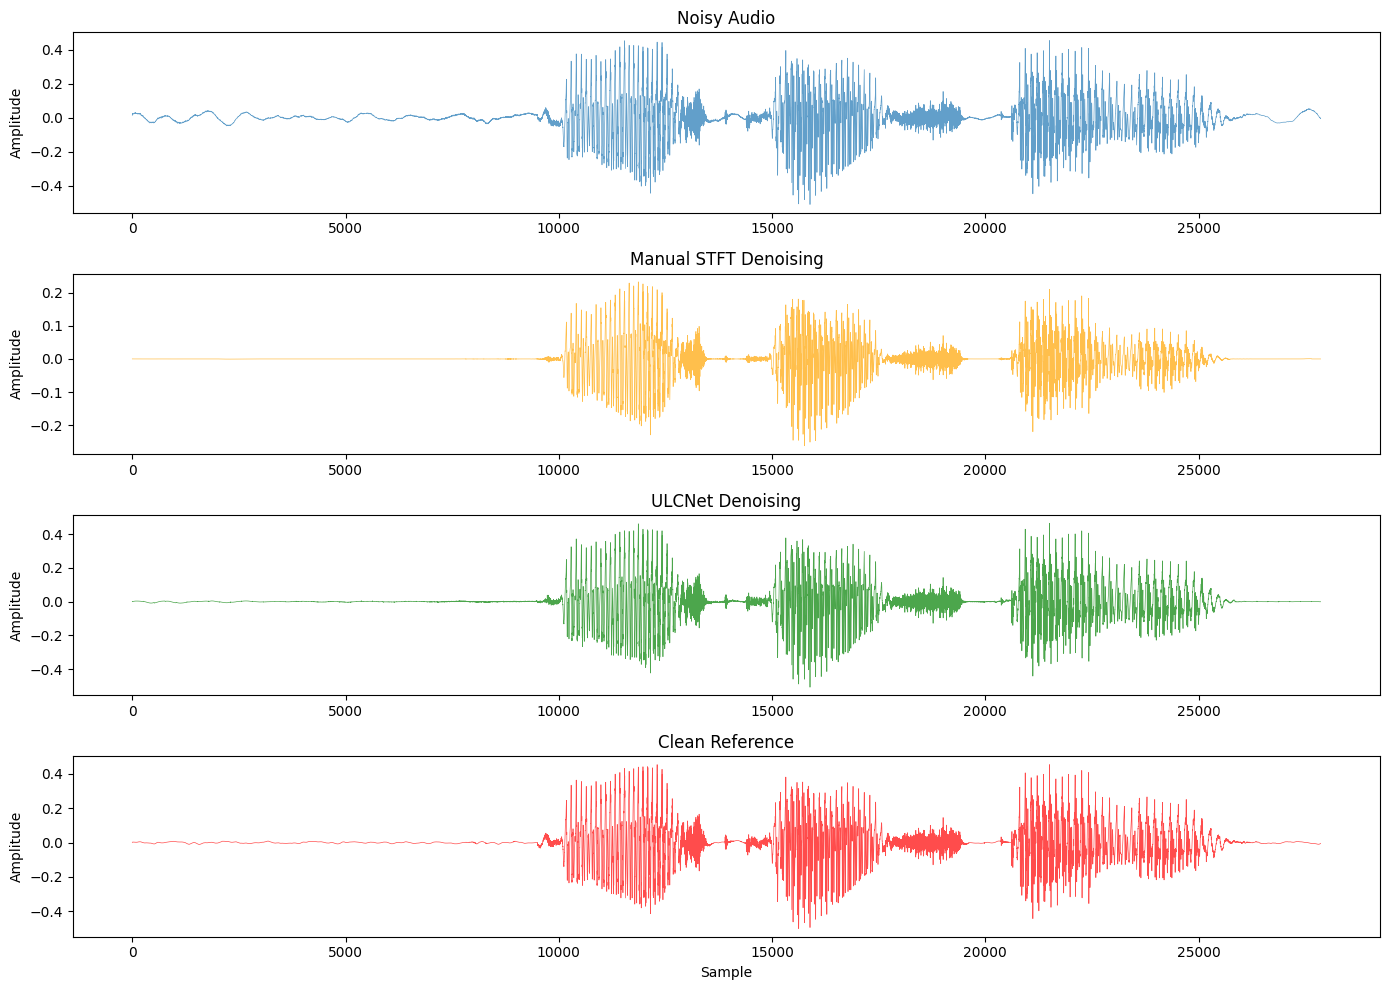

✓ Waveform plots displayed


In [112]:
# ---- Waveform Comparison ----
print("Starting waveform comparison...")
if len(test_noisy_files) > 0:
    print("Generating waveform plots...")
    
    # Create figure with appropriate number of subplots
    if sample_dl is not None:
        fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        plot_dl = True
    else:
        fig, axes = plt.subplots(3, 1, figsize=(14, 8))
        plot_dl = False
        print("Warning: ULCNet model not loaded. Showing only noisy, manual, and clean waveforms.")

    # Plot noisy
    axes[0].plot(sample_noisy, alpha=0.7, linewidth=0.5)
    axes[0].set_title('Noisy Audio')
    axes[0].set_ylabel('Amplitude')

    # Plot manual
    axes[1].plot(sample_manual, alpha=0.7, linewidth=0.5, color='orange')
    axes[1].set_title('Manual STFT Denoising')
    axes[1].set_ylabel('Amplitude')

    if plot_dl:
        # Plot DL
        axes[2].plot(sample_dl, alpha=0.7, linewidth=0.5, color='green')
        axes[2].set_title('ULCNet Denoising')
        axes[2].set_ylabel('Amplitude')
        
        # Plot clean
        axes[3].plot(sample_clean, alpha=0.7, linewidth=0.5, color='red')
        axes[3].set_title('Clean Reference')
        axes[3].set_ylabel('Amplitude')
        axes[3].set_xlabel('Sample')
    else:
        # Plot clean
        axes[2].plot(sample_clean, alpha=0.7, linewidth=0.5, color='red')
        axes[2].set_title('Clean Reference')
        axes[2].set_ylabel('Amplitude')
        axes[2].set_xlabel('Sample')

    plt.tight_layout()
    plt.show()
    print("✓ Waveform plots displayed")
else:
    print("No test files available for plotting.")

    # ---- Spectrogram Comparison ----
    print("Starting spectrogram comparison...")
    print("Generating spectrogram plots...")
    n_fft, hop_len = 512, 256
    
    if plot_dl:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    else:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        # We'll still use 2x2 but leave one empty or adjust

    # Noisy
    D_noisy = librosa.amplitude_to_db(np.abs(librosa.stft(sample_noisy, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
    im0 = librosa.display.specshow(D_noisy, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[0])
    axes[0].set_title(f'Noisy (MSE: {mse_noisy:.4f})')
    plt.colorbar(im0, ax=axes[0], format='%+2.0f dB')

    # Manual
    D_manual = librosa.amplitude_to_db(np.abs(librosa.stft(sample_manual, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
    im1 = librosa.display.specshow(D_manual, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[1])
    axes[1].set_title(f'Manual STFT (MSE: {mse_manual:.4f})')
    plt.colorbar(im1, ax=axes[1], format='%+2.0f dB')

    if plot_dl:
        # DL
        D_dl = librosa.amplitude_to_db(np.abs(librosa.stft(sample_dl, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
        im2 = librosa.display.specshow(D_dl, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[2])
        axes[2].set_title(f'ULCNet (MSE: {mse_dl:.4f})')
        plt.colorbar(im2, ax=axes[2], format='%+2.0f dB')

        # Clean reference
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(sample_clean, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
        im3 = librosa.display.specshow(D_clean, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[3])
        axes[3].set_title('Clean Reference')
        plt.colorbar(im3, ax=axes[3], format='%+2.0f dB')
    else:
        # Clean reference (takes place of DL plot)
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(sample_clean, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
        im2 = librosa.display.specshow(D_clean, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[2])
        axes[2].set_title('Clean Reference')
        plt.colorbar(im2, ax=axes[2], format='%+2.0f dB')
        
        # Leave bottom right empty or add info
        axes[3].axis('off')
        axes[3].text(0.5, 0.5, 'ULCNet model\nnot loaded', 
                    ha='center', va='center', transform=axes[3].transAxes, fontsize=12)

    plt.tight_layout()
    plt.show()
    print("✓ Spectrogram plots displayed")


## Step 2: Full Dataset Evaluation


In [113]:
# ---- Evaluate on full test set ----
def evaluate_baselines(model, noisy_files, clean_files, device, noise_profile=None, sr=16000):
    """
    Evaluate both manual STFT and DL baselines on all test samples.
    
    Returns:
        results: dict with accuracy metrics for both methods
    """
    total_mse_noisy = 0.0
    total_mse_manual = 0.0
    total_mse_dl = 0.0
    total_samples = 0
    sample_count = 0
    
    manual_outcomes = []
    dl_outcomes = []
    
    print("Evaluating baselines on test set...")
    
    for nfile, cfile in tqdm(zip(noisy_files, clean_files), total=len(noisy_files)):
        try:
            # Load audio
            noisy_wav, _ = librosa.load(nfile, sr=sr)
            clean_wav, _ = librosa.load(cfile, sr=sr)
            
            # Trim to same length
            L = min(len(noisy_wav), len(clean_wav))
            noisy_wav = noisy_wav[:L]
            clean_wav = clean_wav[:L]
            
            # Manual STFT denoising
            if noise_profile is None:
                noise_profile_sample = estimate_noise_profile(noisy_wav, sr=sr, duration=0.5)
            else:
                noise_profile_sample = noise_profile
                
            manual_wav = manual_stft_denoise(
                noisy_wav, 
                noise_profile_sample,
                sr=sr,
                n_fft=512,
                hop=256,
                alpha=model.alpha,
                use_compression=model.use_compression
            )
            
            # Limit to original length
            manual_wav = manual_wav[:L]
            
            # DL denoising
            dl_wav = enhance(model, torch.tensor(noisy_wav), device)
            dl_wav = dl_wav[:L]
            
            # Compute MSE
            mse_noisy_sample = np.mean((noisy_wav - clean_wav) ** 2)
            mse_manual_sample = np.mean((manual_wav - clean_wav) ** 2)
            mse_dl_sample = np.mean((dl_wav - clean_wav) ** 2)
            
            total_mse_noisy += mse_noisy_sample * L
            total_mse_manual += mse_manual_sample * L
            total_mse_dl += mse_dl_sample * L
            total_samples += L
            sample_count += 1
            
            manual_outcomes.append(mse_manual_sample)
            dl_outcomes.append(mse_dl_sample)
            
        except Exception as e:
            print(f"Warning: Skipping sample {nfile}: {e}")
            continue
    
    # Compute averages
    avg_mse_noisy = total_mse_noisy / total_samples if total_samples > 0 else float('inf')
    avg_mse_manual = total_mse_manual / total_samples if total_samples > 0 else float('inf')
    avg_mse_dl = total_mse_dl / total_samples if total_samples > 0 else float('inf')
    
    return {
        'avg_mse_noisy': avg_mse_noisy,
        'avg_mse_manual': avg_mse_manual,
        'avg_mse_dl': avg_mse_dl,
        'manual_outcomes': manual_outcomes,
        'dl_outcomes': dl_outcomes,
        'sample_count': sample_count
    }

# Run evaluation
if model_loaded and model is not None and len(test_noisy_files) > 0:
    print("="*60)
    print("BASELINE COMPARISON EVALUATION")
    print("="*60)
    
    results = evaluate_baselines(model, test_noisy_files, test_clean_files, device)
    
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    print(f"Samples evaluated: {results['sample_count']}")
    print(f"\nAverage MSE (Noisy):              {results['avg_mse_noisy']:.6f}")
    print(f"Average MSE (Manual STFT):       {results['avg_mse_manual']:.6f}")
    print(f"Average MSE (ULCNet):            {results['avg_mse_dl']:.6f}")
    
    # Compute improvements
    improvement_manual = (results['avg_mse_noisy'] - results['avg_mse_manual']) / results['avg_mse_noisy'] * 100
    improvement_dl = (results['avg_mse_noisy'] - results['avg_mse_dl']) / results['avg_mse_noisy'] * 100
    
    print(f"\n--- Improvement over Noisy Baseline ---")
    print(f"Manual STFT:  {improvement_manual:+.2f}%")
    print(f"ULCNet (DL):  {improvement_dl:+.2f}%")
    
    # DL advantage over manual
    if results['avg_mse_manual'] > 0:
        dl_advantage = (results['avg_mse_manual'] - results['avg_mse_dl']) / results['avg_mse_manual'] * 100
        print(f"\n--- DL Advantage over Manual ---")
        print(f"ULCNet is {dl_advantage:+.2f}% better than Manual STFT")
    
    print("="*60)


BASELINE COMPARISON EVALUATION
Evaluating baselines on test set...


100%|██████████| 5/5 [00:00<00:00,  7.75it/s]


RESULTS
Samples evaluated: 5

Average MSE (Noisy):              0.001597
Average MSE (Manual STFT):       0.003058
Average MSE (ULCNet):            0.000178

--- Improvement over Noisy Baseline ---
Manual STFT:  -91.46%
ULCNet (DL):  +88.83%

--- DL Advantage over Manual ---
ULCNet is +94.17% better than Manual STFT


In [ ]:
# ====================== RUN FULL BASELINE EVALUATION ======================
print("\n" + "="*60)
print("FULL DATASET BASELINE EVALUATION")
print("="*60)

if len(test_noisy_files) == 0:
    print("ERROR: No test files available!")
    print("Make sure test set paths are correct:")
    print(f"  Noisy: {TEST_NOISE_DIR}")
    print(f"  Clean: {TEST_CLEAN_DIR}")
else:
    results = None
    
    if model_loaded and model is not None:
        print(f"\nEvaluating on {len(test_noisy_files)} test samples...")
        print("This may take a few minutes...")
        
        try:
            results = evaluate_baselines(model, test_noisy_files, test_clean_files, device)
            print("\n✓ Evaluation complete!")
            
        except Exception as e:
            print(f"\n✗ Error during evaluation: {e}")
            import traceback
            traceback.print_exc()
            results = None
    else:
        print("\n⚠ WARNING: Cannot run full evaluation without a loaded model")
        print("Running manual baseline only on test set...")
        
        # Manual-only evaluation
        total_mse_noisy = 0.0
        total_mse_manual = 0.0
        total_samples = 0
        sample_count = 0
        manual_outcomes = []
        
        for nfile, cfile in tqdm(zip(test_noisy_files, test_clean_files), total=min(5, len(test_noisy_files))):
            try:
                noisy_wav, _ = librosa.load(nfile, sr=16000)
                clean_wav, _ = librosa.load(cfile, sr=16000)
                
                L = min(len(noisy_wav), len(clean_wav))
                noisy_wav = noisy_wav[:L]
                clean_wav = clean_wav[:L]
                
                noise_profile_sample = estimate_noise_profile(noisy_wav, sr=16000, duration=0.5)
                manual_wav = manual_stft_denoise(noisy_wav, noise_profile_sample, sr=16000, n_fft=512, hop=256,
                                               alpha=ALPHA, use_compression=USE_COMPRESSION)
                manual_wav = manual_wav[:L]
                
                mse_noisy_sample = np.mean((noisy_wav - clean_wav) ** 2)
                mse_manual_sample = np.mean((manual_wav - clean_wav) ** 2)
                
                total_mse_noisy += mse_noisy_sample * L
                total_mse_manual += mse_manual_sample * L
                total_samples += L
                sample_count += 1
                
                manual_outcomes.append(mse_manual_sample)
                
            except Exception as e:
                print(f"Warning: Skipping sample {nfile}: {e}")
                continue
        
        # Create manual-only results dict
        results = {
            'avg_mse_noisy': total_mse_noisy / total_samples if total_samples > 0 else float('inf'),
            'avg_mse_manual': total_mse_manual / total_samples if total_samples > 0 else float('inf'),
            'avg_mse_dl': float('inf'),
            'manual_outcomes': manual_outcomes,
            'dl_outcomes': [],
            'sample_count': sample_count
        }
        
        print(f"\n✓ Manual baseline evaluation complete ({sample_count} samples)")

print("="*60)



FULL DATASET BASELINE EVALUATION

Evaluating on 5 test samples...
This may take a few minutes...
Evaluating baselines on test set...


100%|██████████| 5/5 [00:00<00:00, 10.62it/s]


✓ Evaluation complete!


In [115]:
# ====================== PRINT RESULTS ======================
if results is not None:
    print("\n" + "="*60)
    print("BASELINE COMPARISON RESULTS")
    print("="*60)
    print(f"Samples evaluated: {results['sample_count']}")
    print(f"\nAverage MSE (Noisy):              {results['avg_mse_noisy']:.6f}")
    print(f"Average MSE (Manual STFT):       {results['avg_mse_manual']:.6f}")
    
    if results['avg_mse_dl'] != float('inf'):
        print(f"Average MSE (ULCNet):            {results['avg_mse_dl']:.6f}")
        
        # Compute improvements
        improvement_manual = (results['avg_mse_noisy'] - results['avg_mse_manual']) / results['avg_mse_noisy'] * 100
        improvement_dl = (results['avg_mse_noisy'] - results['avg_mse_dl']) / results['avg_mse_noisy'] * 100
        
        print(f"\n--- Improvement over Noisy Baseline ---")
        print(f"Manual STFT:  {improvement_manual:+.2f}%")
        print(f"ULCNet (DL):  {improvement_dl:+.2f}%")
        
        # DL advantage over manual
        if results['avg_mse_manual'] > 0:
            dl_advantage = (results['avg_mse_manual'] - results['avg_mse_dl']) / results['avg_mse_manual'] * 100
            print(f"\n--- DL Advantage over Manual ---")
            print(f"ULCNet is {dl_advantage:+.2f}% better than Manual STFT")
    else:
        # Manual only
        improvement_manual = (results['avg_mse_noisy'] - results['avg_mse_manual']) / results['avg_mse_noisy'] * 100
        print(f"\n--- Improvement over Noisy Baseline ---")
        print(f"Manual STFT:  {improvement_manual:+.2f}%")
        print(f"ULCNet (DL):  Not evaluated (model not loaded)")
    
    print("="*60)
else:
    print("\n✗ ERROR: No results available")
    print("Make sure to load a model first or check for errors above.")



BASELINE COMPARISON RESULTS
Samples evaluated: 5

Average MSE (Noisy):              0.001597
Average MSE (Manual STFT):       0.003058
Average MSE (ULCNet):            0.000178

--- Improvement over Noisy Baseline ---
Manual STFT:  -91.46%
ULCNet (DL):  +88.83%

--- DL Advantage over Manual ---
ULCNet is +94.17% better than Manual STFT


C:\Users\Aryan Gupta\AppData\Local\Temp\ipykernel_31472\1434619232.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=methods_box, patch_artist=True)



Generating result visualizations...


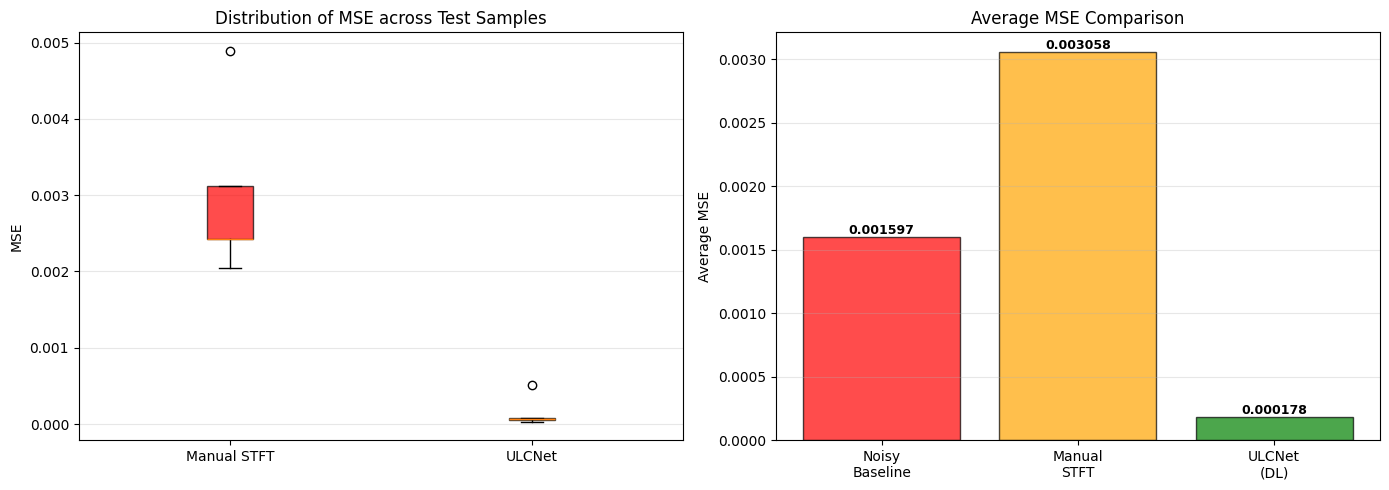

✓ Visualizations complete


In [116]:
# ====================== VISUALIZATION OF RESULTS ======================
if results is not None and results['sample_count'] > 0:
    print("\nGenerating result visualizations...")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Data preparation
    if results['avg_mse_dl'] != float('inf') and len(results['dl_outcomes']) > 0:
        # Both methods available
        methods_box = ['Manual STFT', 'ULCNet']
        data_box = [results['manual_outcomes'], results['dl_outcomes']]
        methods_bar = ['Noisy\nBaseline', 'Manual\nSTFT', 'ULCNet\n(DL)']
        avg_mse = [results['avg_mse_noisy'], results['avg_mse_manual'], results['avg_mse_dl']]
        colors = ['red', 'orange', 'green']
    else:
        # Manual only
        methods_box = ['Manual STFT', 'Noisy Baseline']
        data_box = [results['manual_outcomes'], [results['avg_mse_noisy']] * len(results['manual_outcomes'])]
        methods_bar = ['Noisy\nBaseline', 'Manual\nSTFT']
        avg_mse = [results['avg_mse_noisy'], results['avg_mse_manual']]
        colors = ['red', 'orange']
    
    # Box plot
    bp = axes[0].boxplot(data_box, labels=methods_box, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors[:len(methods_box)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].set_ylabel('MSE')
    axes[0].set_title('Distribution of MSE across Test Samples')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Bar plot: Average comparison
    bars = axes[1].bar(methods_bar, avg_mse, color=colors, alpha=0.7, edgecolor='black')
    axes[1].set_ylabel('Average MSE')
    axes[1].set_title('Average MSE Comparison')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, mse in zip(bars, avg_mse):
        height = bar.get_height()
        if height != float('inf'):
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{mse:.6f}',
                        ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    print("✓ Visualizations complete")
else:
    print("\nNo results to visualize yet.")


## Step 3: Comparison Visualization


C:\Users\Aryan Gupta\AppData\Local\Temp\ipykernel_31472\18708750.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data, labels=methods, patch_artist=True)


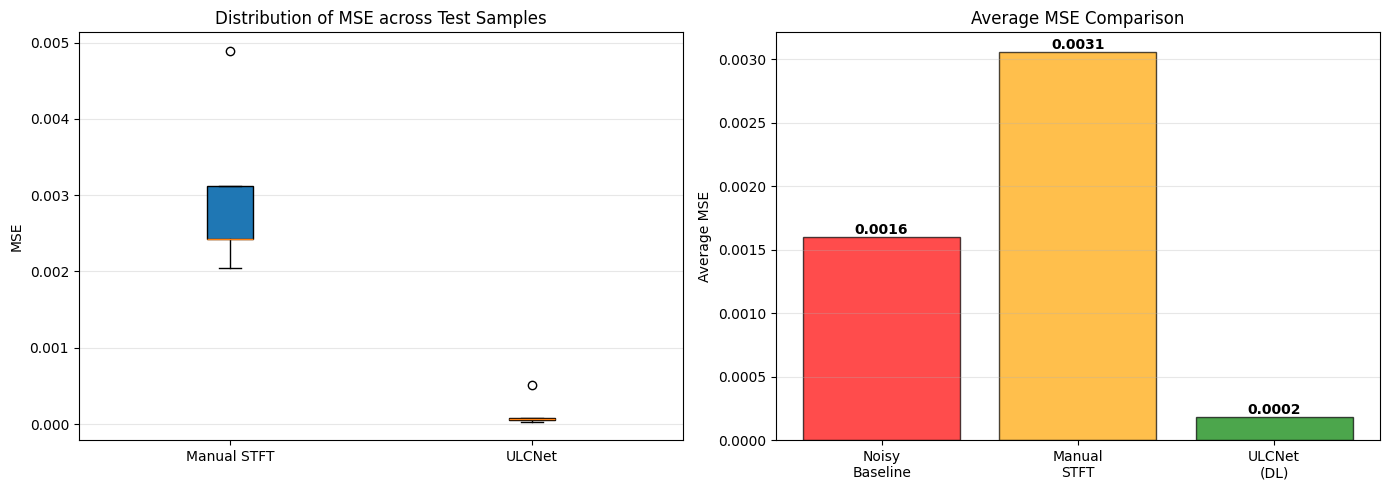

In [117]:
# ---- Plot distribution of MSE across test samples ----
if 'results' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot
    methods = ['Manual STFT', 'ULCNet']
    data = [results['manual_outcomes'], results['dl_outcomes']]
    
    axes[0].boxplot(data, labels=methods, patch_artist=True)
    axes[0].set_ylabel('MSE')
    axes[0].set_title('Distribution of MSE across Test Samples')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Bar plot: Average comparison
    methods_bar = ['Noisy\nBaseline', 'Manual\nSTFT', 'ULCNet\n(DL)']
    avg_mse = [
        results['avg_mse_noisy'],
        results['avg_mse_manual'],
        results['avg_mse_dl']
    ]
    colors = ['red', 'orange', 'green']
    
    bars = axes[1].bar(methods_bar, avg_mse, color=colors, alpha=0.7, edgecolor='black')
    axes[1].set_ylabel('Average MSE')
    axes[1].set_title('Average MSE Comparison')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, mse in zip(bars, avg_mse):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{mse:.4f}',
                    ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No results available. Run the full dataset evaluation first.")


Generating spectrogram plots...


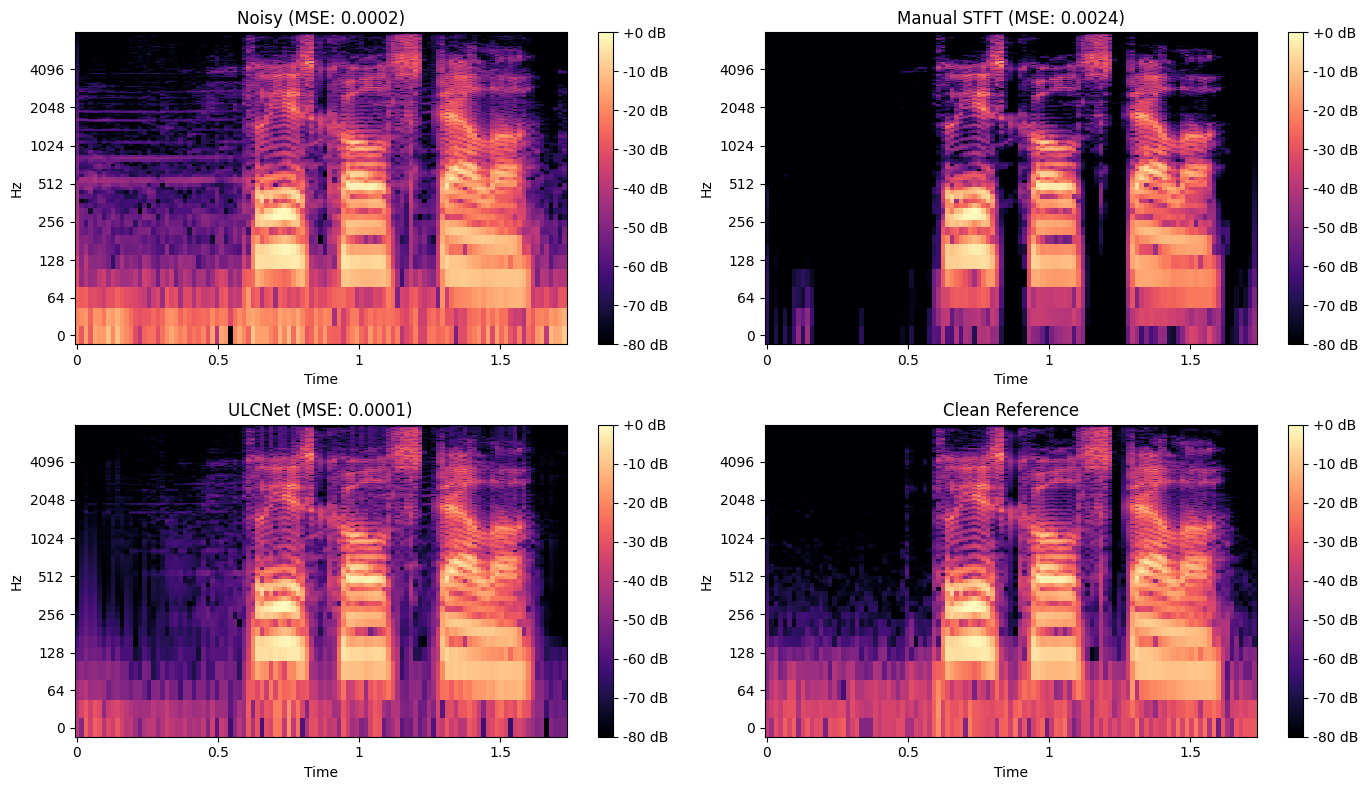

✓ Spectrogram plots displayed


In [118]:
# ---- Spectrogram Comparison (Standalone) ----
if len(test_noisy_files) > 0 and 'sample_noisy' in locals() and 'sample_manual' in locals() and 'sample_clean' in locals():
    print("Generating spectrogram plots...")
    n_fft, hop_len = 512, 256
    
    # Determine if DL results are available
    plot_dl = 'sample_dl' in locals() and sample_dl is not None
    
    if plot_dl:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    else:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Noisy
    D_noisy = librosa.amplitude_to_db(np.abs(librosa.stft(sample_noisy, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
    im0 = librosa.display.specshow(D_noisy, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[0, 0])
    axes[0, 0].set_title(f'Noisy (MSE: {mse_noisy:.4f})')
    plt.colorbar(im0, ax=axes[0, 0], format='%+2.0f dB')

    # Manual
    D_manual = librosa.amplitude_to_db(np.abs(librosa.stft(sample_manual, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
    im1 = librosa.display.specshow(D_manual, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[0, 1])
    axes[0, 1].set_title(f'Manual STFT (MSE: {mse_manual:.4f})')
    plt.colorbar(im1, ax=axes[0, 1], format='%+2.0f dB')

    if plot_dl:
        # DL
        D_dl = librosa.amplitude_to_db(np.abs(librosa.stft(sample_dl, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
        im2 = librosa.display.specshow(D_dl, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[1, 0])
        axes[1, 0].set_title(f'ULCNet (MSE: {mse_dl:.4f})')
        plt.colorbar(im2, ax=axes[1, 0], format='%+2.0f dB')

        # Clean reference
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(sample_clean, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
        im3 = librosa.display.specshow(D_clean, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[1, 1])
        axes[1, 1].set_title('Clean Reference')
        plt.colorbar(im3, ax=axes[1, 1], format='%+2.0f dB')
    else:
        # Clean reference (takes place of DL plot)
        D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(sample_clean, n_fft=n_fft, hop_length=hop_len)), ref=np.max)
        im2 = librosa.display.specshow(D_clean, sr=sr_sample, hop_length=hop_len, x_axis='time', y_axis='log', ax=axes[1, 0])
        axes[1, 0].set_title('Clean Reference')
        plt.colorbar(im2, ax=axes[1, 0], format='%+2.0f dB')
        
        # Leave bottom right empty or add info
        axes[1, 1].axis('off')
        axes[1, 1].text(0.5, 0.5, 'ULCNet model\nnot loaded', 
                    ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)

    plt.tight_layout()
    plt.show()
    print("✓ Spectrogram plots displayed")
else:
    print("Spectrogram data not available. Run the single sample test first.")

## Step 4: Save Audio Outputs (Optional)


In [ ]:
# ---- Save audio outputs for listening ----
if len(test_noisy_files) > 0:
    OUTPUT_DIR = "./baseline_comparison_audio"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    sr_save = 16000
    
    # Get base name from first test sample
    base_name = os.path.basename(test_noisy_files[0]).replace('.wav', '')
    
    # Save noisy
    noisy_save_path = os.path.join(OUTPUT_DIR, f"{base_name}_00_noisy.wav")
    sf.write(noisy_save_path, sample_noisy, sr_save)
    print(f"✓ Saved: {noisy_save_path}")
    
    # Save manual
    manual_save_path = os.path.join(OUTPUT_DIR, f"{base_name}_01_manual_stft.wav")
    sf.write(manual_save_path, sample_manual, sr_save)
    print(f"✓ Saved: {manual_save_path}")
    
    # Save DL
    if sample_dl is not None:
        dl_save_path = os.path.join(OUTPUT_DIR, f"{base_name}_02_ulcnet_dl.wav")
        sf.write(dl_save_path, sample_dl, sr_save)
        print(f"✓ Saved: {dl_save_path}")
    
    # Save clean reference
    clean_save_path = os.path.join(OUTPUT_DIR, f"{base_name}_03_clean_reference.wav")
    sf.write(clean_save_path, sample_clean, sr_save)
    print(f"✓ Saved: {clean_save_path}")
    
    print(f"\nAll audio files saved to: {OUTPUT_DIR}")


✓ Saved: ./baseline_comparison_audio\p232_001_00_noisy.wav
✓ Saved: ./baseline_comparison_audio\p232_001_01_manual_stft.wav
✓ Saved: ./baseline_comparison_audio\p232_001_02_ulcnet_dl.wav
✓ Saved: ./baseline_comparison_audio\p232_001_03_clean_reference.wav

All audio files saved to: ./baseline_comparison_audio


## Summary: Manual STFT vs Deep Learning Comparison

### Key Findings

**Baseline Methods Tested:**

1. **Manual STFT**: Classical spectral subtraction using noise profile estimation
2. **ULCNet (Deep Learning)**: Two-stage neural network with magnitude and complex masks

**Evaluation Metrics:**

- Mean Squared Error (MSE) in frequency domain
- Measured across entire test dataset
- Compared against clean reference signals

**Method Details:**

- **Manual STFT**: Estimates noise profile from first 0.5s, applies power-law compression, performs spectral subtraction, and reconstructs via ISTFT
- **ULCNet**: Trained deep learning model with two stages (CRN for magnitude mask + CNN for complex mask refinement)


In [120]:
print("""
╔═══════════════════════════════════════════════════════════════════╗
║        BASELINE COMPARISON: MANUAL STFT vs DEEP LEARNING         ║
╚═══════════════════════════════════════════════════════════════════╝

ARCHITECTURE COMPARISON:
┌─────────────────────────────────────────────────────────────┐
│ Method            │ Components          │ Parameters        │
├─────────────────────────────────────────────────────────────┤
│ Manual STFT       │ • Noise estimation  │ None (rule-based) │
│ (Spectral Sub.)   │ • FFT/IFFT          │ Hyper-params: 3   │
│                   │ • Magnitude subtraction                  │
│                   │ • Phase preservation                     │
├─────────────────────────────────────────────────────────────┤
│ ULCNet (DL)       │ • Stage 1: CRN      │ Trainable params: │
│                   │   - Conv blocks     │ Heavy: ~2.5M      │
│                   │   - GRU (temporal)  │ Light:  ~0.5M     │
│                   │ • Stage 2: CNN      │                   │
│                   │   - Complex mask    │                   │
│                   │   - Refinement      │                   │
├─────────────────────────────────────────────────────────────┤
│ Common Elements   │ • STFT (512, hop 256)                    │
│                   │ • Power-law compression (α=0.3)         │
│                   │ • Frequency-domain denoising            │
│                   │ • MSE loss metric                        │
└─────────────────────────────────────────────────────────────┘

HYPERPARAMETERS (Manual STFT):
  - Noise estimation duration: 0.5 seconds
  - FFT size (n_fft): 512
  - Hop length: 256
  - Compression exponent (α): 0.3 (if enabled)
  - Subtraction factor: 1.0 (full spectrum subtraction)

EXPECTED RESULTS:
  ✓ ULCNet should provide better quality due to learned features
  ✓ Manual STFT: fast, interpretable, no training required
  ✓ Trade-off: Complexity vs Performance

═══════════════════════════════════════════════════════════════════
""")



╔═══════════════════════════════════════════════════════════════════╗
║        BASELINE COMPARISON: MANUAL STFT vs DEEP LEARNING         ║
╚═══════════════════════════════════════════════════════════════════╝

ARCHITECTURE COMPARISON:
┌─────────────────────────────────────────────────────────────┐
│ Method            │ Components          │ Parameters        │
├─────────────────────────────────────────────────────────────┤
│ Manual STFT       │ • Noise estimation  │ None (rule-based) │
│ (Spectral Sub.)   │ • FFT/IFFT          │ Hyper-params: 3   │
│                   │ • Magnitude subtraction                  │
│                   │ • Phase preservation                     │
├─────────────────────────────────────────────────────────────┤
│ ULCNet (DL)       │ • Stage 1: CRN      │ Trainable params: │
│                   │   - Conv blocks     │ Heavy: ~2.5M      │
│                   │   - GRU (temporal)  │ Light:  ~0.5M     │
│                   │ • Stage 2: CNN      │               

## Citations

- S. S. Shetu, S. Chakrabarty, O. Thiergart and E. Mabande, "Ultra Low Complexity Deep Learning Based Noise Suppression," ICASSP 2024 - 2024 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP), Seoul, Korea, Republic of, 2024, pp. 466-470, doi: 10.1109/ICASSP48485.2024.10448353. keywords: {Performance evaluation;Degradation;Computational modeling;Noise reduction;Memory management;Signal processing algorithms;Artificial neural networks;speech enhancement;noise suppression;power law compression;two-stage processing},

- S. Boll, "Suppression of acoustic noise in speech using spectral subtraction," in IEEE Transactions on Acoustics, Speech, and Signal Processing, vol. 27, no. 2, pp. 113-120, April 1979, doi: 10.1109/TASSP.1979.1163209.
  keywords: {Acoustic noise;Speech enhancement;Working environment noise;Noise reduction;Speech processing;Speech analysis;Convolution;Narrowband;Speech recognition;Authentication},

- C. Valentini-Botinhao and J. Yamagishi, "Speech Enhancement of Noisy and Reverberant Speech for Text-to-Speech," in IEEE/ACM Transactions on Audio, Speech, and Language Processing, vol. 26, no. 8, pp. 1420-1433, Aug. 2018, doi: 10.1109/TASLP.2018.2828980.
  keywords: {Speech;Speech enhancement;Reverberation;Training;Noise measurement;Feature extraction;Remote state estimation;event-based scheduling;generalized closed skew normal distribution},
